# CIFAR-10

Датасет CIFAR-10 состоит из цветных картинок 32x32, разделенных на 10 классов:

__airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck__

# Импорты

In [1]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.models as M
import tensorflow.keras.layers as L
import tensorflow.keras.backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


# Загружаем данные

In [2]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [3]:
print("Трейн:", x_train.shape, y_train.shape)
print("Тест:", x_test.shape, y_test.shape)

Трейн: (50000, 32, 32, 3) (50000, 1)
Тест: (10000, 32, 32, 3) (10000, 1)


In [4]:
NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

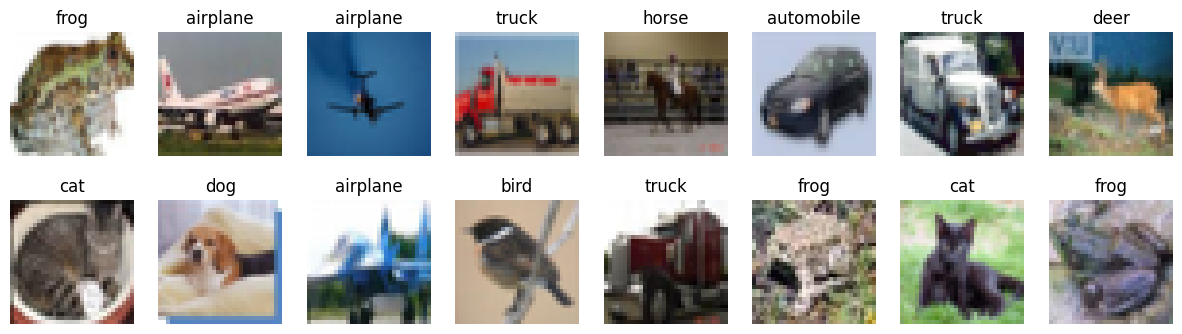

In [5]:
# посмотрим на примеры картинок
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index, 0]])
plt.show()

# Готовим данные

Нормализация картинки: $$x_{norm} = \frac{x}{255} - 0.5$$

А еще нужно превратить метки в one-hot вектора при помощи __keras.utils.to_categorical__.

In [6]:
# нормализуем входы
x_train2 = x_train.astype('float32') / 255 - 0.5
x_test2 = x_test.astype('float32') / 255 - 0.5

# конвертируем метки в np.array (?, NUM_CLASSES)
y_train2 = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test2 = keras.utils.to_categorical(y_test, NUM_CLASSES)

# Задаем *дефолтную* архитектуру сети

In [7]:
# слои, которые нам пригодятся
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

Шпаргалка по используемым слоям:
- [Conv2D](https://keras.io/layers/convolutional/#conv2d) - сверточный слой:
    - **filters**: количество фильтров на выходе;
    - **kernel_size**: размер скользящего окна;
    - **padding**: padding="same" добивает нулями, чтобы ширина и высота на выходе не изменились, padding='valid' берет только окна, которые полностью помещаются в картинке;
    - **activation**: "relu", "tanh", итд;
    - **input_shape**: размер входа вида (W, H, C_in).
- [MaxPooling2D](https://keras.io/layers/pooling/#maxpooling2d) - пулинг
- [Flatten](https://keras.io/layers/core/#flatten) - все оси, кроме батча (первой) вытягиваются в один вектор.
- [Dense](https://keras.io/layers/core/#dense) - плотный, активацию можно задать через activation="elu" или activation="softmax".
- [Dropout](https://keras.io/layers/core/#dropout) - дропаут регуляризация (без нее сеть сильно переобучается), позже узнаем какой у нее смысл.

Дефолтная модель принимает на вход цветную картинку __(None, 32, 32, 3)__ и предсказывает вероятности 10 классов __(None, 10)__.

Состоит из
1. __4__ сверточных слоя с окном __(3, 3)__ с нарастающим количеством фильтров: __(16, 32, 32, 64)__, используйтся "same" паддинг;

2. После каждых 2 сверточных слоев __2x2__ макс пулинг  (conv-conv-pool схема);

3. Применяется __Flatten__ перед первым плотным слое;

4. Плотный слой из __256__ нейронов и еще один из __10__ нейронов для предсказания выходов. Используйте __activation='relu'__ для первого плотного слоя.

5. Для регуляризации сети используется Dropout после каждого пулинг слоя (с параметром** 0.25**) и между плотными слоями на выходе (с параметром **0.5**).

В дальнейшем будем называть эту архитектуру **дефолтной** и будем исследовать небольшие изменения в ней!

In [8]:
def make_default_model():
    model = Sequential()
    model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', input_shape=(32,32,3)))
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same'))
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same'))
    model.add(Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same'))
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    return model

In [9]:
K.clear_session()
model = make_default_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,234 (4.14 MB)

 Trainable params: 1,084,234 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

# Тренируем модель

In [10]:
def train_model(make_model_func=make_default_model, optimizer="adam"):
  BATCH_SIZE = 32
  EPOCHS = 10

  K.clear_session()
  model = make_model_func()

  model.compile(
      loss='categorical_crossentropy',
      optimizer=optimizer,
      metrics=['accuracy']
  )

  histori = model.fit(
      x_train2, y_train2,  # нормализованные данные
      batch_size=BATCH_SIZE,
      epochs=EPOCHS,
      validation_data=(x_test2, y_test2),
      shuffle=False
  )

  return model, histori

Посмотрим, что будет с дефолтной моделью (модель = make_default_model, оптимайзер = "adam") и как измениться ее точность если ее немного поменять:



1.   Если изменить в дефолтной архитектуре **relu активацию на sigmoid**;
2.   Если изменить в дефолтной архитектуре **adam оптимайзер на sgd**;
3.   Если добавить к дефолтной архитектуре **батч нормализацию** после каждого сверточного слоя и после перового полносвязного (model.add(BatchNormalization()));
4.   Если добавить к дефолтной архитектуре **батч нормализацию** и смените **relu активацию на sigmoid**;
5.   Если добавить к дефолтной модели **батч нормализацию** и для Conv слоев **relu активацию**.
  
*Будем использовать свою функцию для каждого изменения архитектуры!*


In [11]:
# учим дефолтную архитектуру
m_defolt, h_defolt = train_model()

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.4457 - loss: 1.5472 - val_accuracy: 0.6206 - val_loss: 1.0774
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6233 - loss: 1.0763 - val_accuracy: 0.6642 - val_loss: 0.9842
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6582 - loss: 0.9868 - val_accuracy: 0.6739 - val_loss: 0.9694
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6764 - loss: 0.9322 - val_accuracy: 0.7079 - val_loss: 0.8644
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6959 - loss: 0.8772 - val_accuracy: 0.7146 - val_loss: 0.8590
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7094 - loss: 0.8420 - val_accuracy: 0.7100 - val_loss: 0.8778
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7151 - loss: 0.8143 - val_accuracy: 0.7191 - val_loss: 0.8523
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7296 - loss: 0.7811 -

In [12]:
def make_sigmoid_model():
    model = Sequential()
    model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', input_shape=(32,32,3)))
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same'))
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same'))
    model.add(Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same'))
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(256, activation='sigmoid'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    return model

In [13]:
# учим sigmoid
m_sigm, h_sigm = train_model(make_sigmoid_model)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.4016 - loss: 1.6789 - val_accuracy: 0.6199 - val_loss: 1.0683
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5930 - loss: 1.1594 - val_accuracy: 0.6480 - val_loss: 0.9922
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6313 - loss: 1.0602 - val_accuracy: 0.6682 - val_loss: 0.9475
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6432 - loss: 1.0238 - val_accuracy: 0.6685 - val_loss: 0.9393
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6471 - loss: 1.0016 - val_accuracy: 0.6780 - val_loss: 0.9230
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6515 - loss: 0.9925 - val_accuracy: 0.6690 - val_loss: 0.9465
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6471 - loss: 1.0149 - val_accuracy: 0.6807 - val_loss: 0.9202
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6465 - loss: 1.0103 -

In [14]:
# учим sgd
m_sgd, h_sgd = train_model(optimizer="sgd")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.2750 - loss: 2.0003 - val_accuracy: 0.4596 - val_loss: 1.5418
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4441 - loss: 1.5634 - val_accuracy: 0.5200 - val_loss: 1.3624
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5062 - loss: 1.3969 - val_accuracy: 0.5543 - val_loss: 1.2617
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5461 - loss: 1.2828 - val_accuracy: 0.5950 - val_loss: 1.1457
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5726 - loss: 1.2065 - val_accuracy: 0.6208 - val_loss: 1.0803
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6031 - loss: 1.1244 - val_accuracy: 0.6580 - val_loss: 0.9967
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6229 - loss: 1.0720 - val_accuracy: 0.6477 - val_loss: 0.9986
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6413 - loss: 1.0288 -

In [15]:
def make_bn_model():
    model = Sequential()
    model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    return model

In [16]:
# учим bn
m_bn, h_bn = train_model(make_bn_model)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.3997 - loss: 1.8211 - val_accuracy: 0.6031 - val_loss: 1.1348
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5921 - loss: 1.1709 - val_accuracy: 0.6586 - val_loss: 0.9917
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6237 - loss: 1.0836 - val_accuracy: 0.6710 - val_loss: 0.9784
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6452 - loss: 1.0254 - val_accuracy: 0.6953 - val_loss: 0.8908
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6663 - loss: 0.9707 - val_accuracy: 0.6952 - val_loss: 0.8712
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6792 - loss: 0.9247 - val_accuracy: 0.6982 - val_loss: 0.8655
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6927 - loss: 0.8797 - val_accuracy: 0.7121 - val_loss: 0.8356
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7061 - loss: 0.8482 

In [17]:
def make_sigmoid_bn_model():
    model = Sequential()
    model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(256, activation='sigmoid'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    return model

In [18]:
# учим sigmoid + bn
m_sigm_bn, h_sigm_bn = train_model(make_sigmoid_bn_model)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.3685 - loss: 1.8926 - val_accuracy: 0.5823 - val_loss: 1.2081
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5534 - loss: 1.2754 - val_accuracy: 0.6035 - val_loss: 1.1157
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5958 - loss: 1.1589 - val_accuracy: 0.6566 - val_loss: 0.9871
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6208 - loss: 1.0982 - val_accuracy: 0.6661 - val_loss: 0.9428
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6367 - loss: 1.0441 - val_accuracy: 0.6795 - val_loss: 0.9265
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6473 - loss: 1.0131 - val_accuracy: 0.6947 - val_loss: 0.8794
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6632 - loss: 0.9772 - val_accuracy: 0.6879 - val_loss: 0.8915
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6698 - loss: 0.9488 -

In [19]:
def make_bn_relu_model():
    model = Sequential()
    model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    return model

In [20]:
m_bn_relu, h_bn_relu = train_model(make_bn_relu_model)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.4066 - loss: 1.8298 - val_accuracy: 0.6276 - val_loss: 1.0418
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6311 - loss: 1.0508 - val_accuracy: 0.6681 - val_loss: 0.9422
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6868 - loss: 0.9066 - val_accuracy: 0.7406 - val_loss: 0.7413
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7143 - loss: 0.8204 - val_accuracy: 0.7440 - val_loss: 0.7397
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7386 - loss: 0.7488 - val_accuracy: 0.7715 - val_loss: 0.6608
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7592 - loss: 0.6843 - val_accuracy: 0.7777 - val_loss: 0.6409
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7785 - loss: 0.6365 - val_accuracy: 0.7867 - val_loss: 0.6154
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7957 - loss: 0.5874 -

In [25]:
def make_bn_elu_model():
    model = Sequential()
    model.add(Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='elu', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='elu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='elu'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='elu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(256, activation='elu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    return model

In [26]:
m_bn_elu, h_bn_elu = train_model(make_bn_elu_model)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.4358 - loss: 1.7612 - val_accuracy: 0.6333 - val_loss: 1.0663
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6346 - loss: 1.0471 - val_accuracy: 0.6972 - val_loss: 0.9027
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6836 - loss: 0.9103 - val_accuracy: 0.7293 - val_loss: 0.7819
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7147 - loss: 0.8187 - val_accuracy: 0.7581 - val_loss: 0.6880
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7369 - loss: 0.7468 - val_accuracy: 0.7635 - val_loss: 0.6831
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7595 - loss: 0.6873 - val_accuracy: 0.7754 - val_loss: 0.6593
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7729 - loss: 0.6446 - val_accuracy: 0.7650 - val_loss: 0.7074
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7919 - loss: 0.5910 -

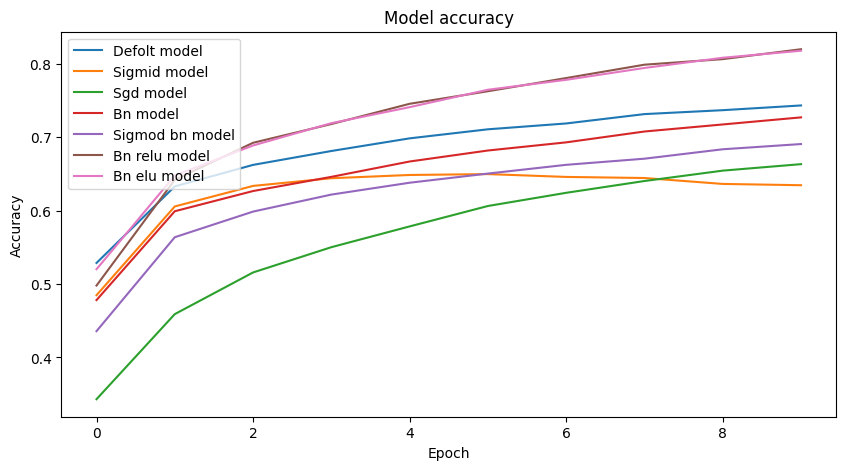

In [30]:
#plt.style.use(['dark_background'])
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(h_defolt.history['accuracy'])
plt.plot(h_sigm.history['accuracy'])
plt.plot(h_sgd.history['accuracy'])
plt.plot(h_bn.history['accuracy'])
plt.plot(h_sigm_bn.history['accuracy'])
plt.plot(h_bn_relu.history['accuracy'])
plt.plot(h_bn_elu.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Defolt model', 'Sigmid model','Sgd model', 'Bn model', 'Sigmod bn model', 'Bn relu model', 'Bn elu model'], loc='upper left')
plt.show()

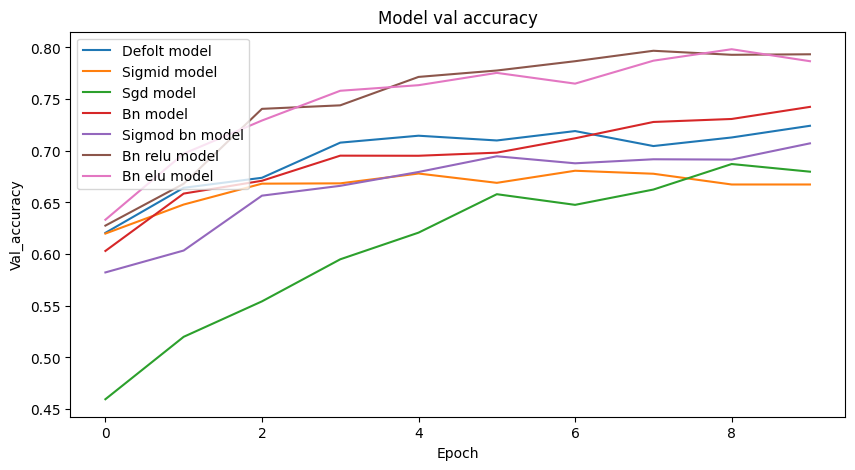

In [29]:
#plt.style.use(['dark_background'])
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(h_defolt.history['val_accuracy'])
plt.plot(h_sigm.history['val_accuracy'])
plt.plot(h_sgd.history['val_accuracy'])
plt.plot(h_bn.history['val_accuracy'])
plt.plot(h_sigm_bn.history['val_accuracy'])
plt.plot(h_bn_relu.history['val_accuracy'])
plt.plot(h_bn_elu.history['val_accuracy'])
plt.title('Model val accuracy')
plt.ylabel('Val_accuracy')
plt.xlabel('Epoch')
plt.legend(['Defolt model', 'Sigmid model','Sgd model', 'Bn model', 'Sigmod bn model', 'Bn relu model', 'Bn elu model'], loc='upper left')
plt.show()

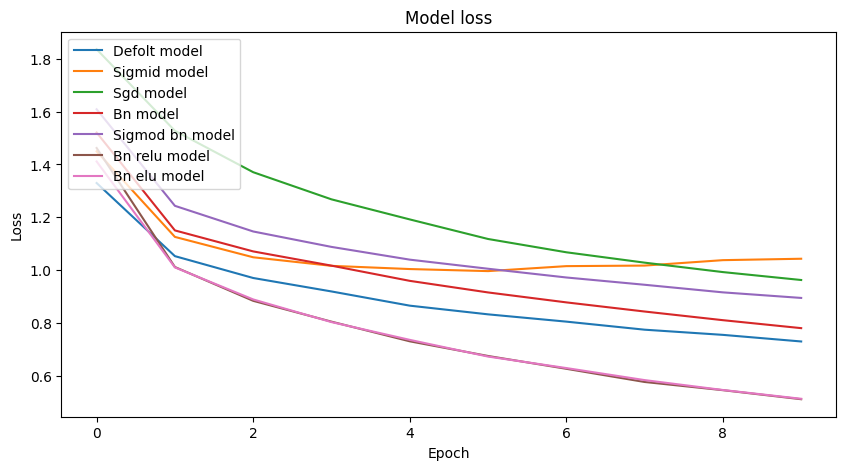

In [31]:
#plt.style.use(['dark_background'])
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(h_defolt.history['loss'])
plt.plot(h_sigm.history['loss'])
plt.plot(h_sgd.history['loss'])
plt.plot(h_bn.history['loss'])
plt.plot(h_sigm_bn.history['loss'])
plt.plot(h_bn_relu.history['loss'])
plt.plot(h_bn_elu.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Defolt model', 'Sigmid model','Sgd model', 'Bn model', 'Sigmod bn model', 'Bn relu model', 'Bn elu model'], loc='upper left')
plt.show()

Выводы
1.   Если изменить в дефолтной архитектуре **relu активацию на sigmoid** - качетсво модели падает относительно дефолтной модели (точность, ошибка хуже);
2.   Если изменить в дефолтной архитектуре **adam оптимайзер на sgd** - наблюдается замедление сходимости и качетсво модели падает относительно дейолтной (точность, ошибка хуже);
3.   Если добавить к дефолтной модели **батч нормализацию** и для Conv слоев **relu активацию** (или **elu активацию**) - точность и ошибка становятся гораздо лчуше  остальных вариантов включая дефолтную;
4.   **relu активация** и **elu активация** показывают себя практически одинаково.
  